<a href="https://colab.research.google.com/github/abdulmm44/Student_dropout_prediction/blob/main/Student_dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement
Higher education institutions face significant financial and reputational losses due to student dropout, yet they lack a systematic way to identify which students are likely to drop out before it happens.
# Hypotheses


1.   Students with lower academic performance in the first semester are more likely to drop out.
2.  Students who are debtors are more likely to drop out than non‑debtors.

3. Scholarship holders are less likely to drop out than non‑scholarship holders.
4. Students enrolled in daytime programs have different dropout rates than evening program students.
5. Older students (age at enrollment) are more likely to drop out than younger students.
6. Higher unemployment rates in the region are associated with higher dropout rates.
7. International students have different dropout rates than domestic students
8. Students with educational special needs are more likely to drop out than those without.










# Exploratory Data Analysis

In [4]:
# Importing the necessary libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif,
    RFE
)

# PCA
from sklearn.decomposition import PCA

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [6]:
# uploading the dataset on google colab from Github
url = "https://raw.githubusercontent.com/abdulmm44/Student_dropout_prediction/main/Student_dropout.csv"
df = pd.read_csv(url)

In [7]:
# understand the data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [8]:
# First five row
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [9]:
df.shape

(4424, 35)

In [10]:
# Statistical summary
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [12]:
# check for the missing data
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nacionality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


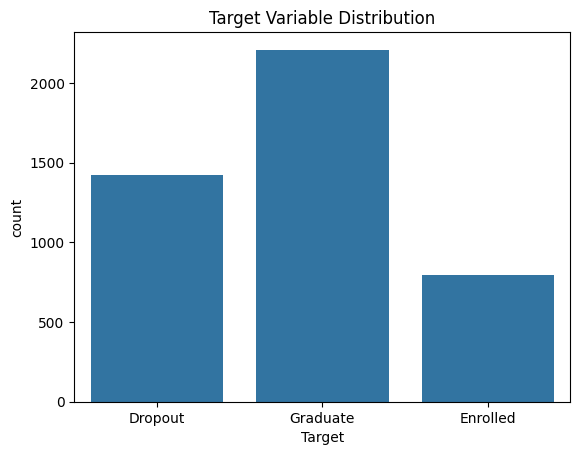

In [13]:
# Target variable analysis
df['Target'].value_counts()

sns.countplot(x='Target',data=df)
plt.title('Target Variable Distribution')
plt.show()

In [14]:
# dictionary mapping the old, messy names to new, clean names
# Format is {'Old Name': 'new_name'}
rename_mapping = {
    'Marital status': 'marital_status',
    'Application mode': 'app_mode',
    'Application order': 'app_order',
    'Daytime/evening attendance': 'daytime_attendance',
    'Previous qualification': 'prev_qual',
    'Nacionality': 'nationality',  # Fixing the spelling error
    "Mother's qualification": 'mother_qual',
    "Father's qualification": 'father_qual',
    "Mother's occupation": 'mother_occ',
    "Father's occupation": 'father_occ',
    'Educational special needs': 'special_needs',
    'Tuition fees up to date': 'tuition_current',
    'Scholarship holder': 'scholarship',
    'Age at enrollment': 'age',

    #  extremely long academic performance columns
    'Curricular units 1st sem (credited)': 'sem1_credited',
    'Curricular units 1st sem (enrolled)': 'sem1_enrolled',
    'Curricular units 1st sem (evaluations)': 'sem1_evals',
    'Curricular units 1st sem (approved)': 'sem1_approved',
    'Curricular units 1st sem (grade)': 'sem1_grade',
    'Curricular units 1st sem (without evaluations)': 'sem1_no_evals',

    'Curricular units 2nd sem (credited)': 'sem2_credited',
    'Curricular units 2nd sem (enrolled)': 'sem2_enrolled',
    'Curricular units 2nd sem (evaluations)': 'sem2_evals',
    'Curricular units 2nd sem (approved)': 'sem2_approved',
    'Curricular units 2nd sem (grade)': 'sem2_grade',
    'Curricular units 2nd sem (without evaluations)': 'sem2_no_evals',

    'Unemployment rate': 'unemployment_rate',
    'Inflation rate': 'inflation_rate',
    'GDP': 'gdp',
    'Target': 'target'
}

# Apply the renaming to both our machine dataset (df)
# inplace=True means it updates the dataframe directly without needing to reassign it
df.rename(columns=rename_mapping, inplace=True)

# Verify the changes
print(df.columns.tolist())

['marital_status', 'app_mode', 'app_order', 'Course', 'daytime_attendance', 'prev_qual', 'nationality', 'mother_qual', 'father_qual', 'mother_occ', 'father_occ', 'Displaced', 'special_needs', 'Debtor', 'tuition_current', 'Gender', 'scholarship', 'age', 'International', 'sem1_credited', 'sem1_enrolled', 'sem1_evals', 'sem1_approved', 'sem1_grade', 'sem1_no_evals', 'sem2_credited', 'sem2_enrolled', 'sem2_evals', 'sem2_approved', 'sem2_grade', 'sem2_no_evals', 'unemployment_rate', 'inflation_rate', 'gdp', 'target']


In [16]:
df

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,nationality,mother_qual,father_qual,mother_occ,...,sem2_credited,sem2_enrolled,sem2_evals,sem2_approved,sem2_grade,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,15,1,1,1,1,1,6,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,15,1,1,19,1,1,10,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,12,1,1,1,22,27,10,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9,1,1,1,22,27,8,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


Transforming the 3 classes target  into two binary  option dropout and not dropout (Retained)

In [17]:
# changing target variable into binary numerical
df['target'] = df['target'].replace({
    'Dropout': 1,
    'Enrolled': 0,
    'Graduate': 0
})

df['target'].value_counts()

,count
target,
0,3003
1,1421


In [18]:
df

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,nationality,mother_qual,father_qual,mother_occ,...,sem2_credited,sem2_enrolled,sem2_evals,sem2_approved,sem2_grade,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,15,1,1,1,1,1,6,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,0
4420,1,1,2,15,1,1,19,1,1,10,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,1
4421,1,1,1,12,1,1,1,22,27,10,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,1
4422,1,1,1,9,1,1,1,22,27,8,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,0


# Decoding the data from source

In [19]:
# the copy of our dataset
df_eda = df.copy()
# 3. mapping dictionaries based on the dataset's documentation
gender_map = {1: 'Male', 0: 'Female'}
yes_no_map = {1: 'Yes', 0: 'No'}
marital_status_map = {
    1: 'Single', 2: 'Married', 3: 'Widower',
    4: 'Divorced', 5: 'Facto Union', 6: 'Legally Separated'
}

# 4. Decode the numeric data back into readable text
df_eda['Gender'] = df_eda['Gender'].map(gender_map)
df_eda['daytime_attendance'] = df_eda['daytime_attendance'].map(yes_no_map)
df_eda['special_needs'] = df_eda['special_needs'].map(yes_no_map)
df_eda['scholarship'] = df_eda['scholarship'].map(yes_no_map)
df_eda['Displaced'] = df_eda['Displaced'].map(yes_no_map)
df_eda['Debtor'] = df_eda['Debtor'].map(yes_no_map)
df_eda['tuition_current'] = df_eda['tuition_current'].map(yes_no_map)
df_eda['marital_status'] = df_eda['marital_status'].map(marital_status_map)

# decode the nationalities
# Group Nationality (1 = Portuguese, everything else = International)
df_eda['nationality_group'] = df_eda['nationality'].apply(
    lambda x: 'Portuguese' if x == 1 else 'International'
)

# Created the new colum to save the target categorical data
# convert numerical back to categorical target variable

df_eda['target'] = df_eda['target'].replace({
    1 : 'Dropout',
    0 : 'Not_Dropout',

})

# Display the newly decoded features next to the new 'target' variable
cols_to_show = ['Gender', 'marital_status', 'scholarship', 'Debtor','special_needs','daytime_attendance', 'tuition_current','nationality_group', 'target']
print(df_eda[cols_to_show].head())

   Gender marital_status scholarship Debtor special_needs daytime_attendance  \
0    Male         Single          No     No            No                Yes   
1    Male         Single          No     No            No                Yes   
2    Male         Single          No     No            No                Yes   
3  Female         Single          No     No            No                Yes   
4  Female        Married          No     No            No                 No   

  tuition_current nationality_group       target  
0             Yes        Portuguese      Dropout  
1              No        Portuguese  Not_Dropout  
2              No        Portuguese      Dropout  
3             Yes        Portuguese  Not_Dropout  
4             Yes        Portuguese  Not_Dropout  


In [20]:
df_eda.head()

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,nationality,mother_qual,father_qual,mother_occ,...,sem2_enrolled,sem2_evals,sem2_approved,sem2_grade,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target,nationality_group
0,Single,8,5,2,Yes,1,1,13,10,6,...,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,Portuguese
1,Single,6,1,11,Yes,1,1,1,3,4,...,6,6,6,13.666667,0,13.9,-0.3,0.79,Not_Dropout,Portuguese
2,Single,1,5,5,Yes,1,1,22,27,10,...,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,Portuguese
3,Single,8,2,15,Yes,1,1,23,27,6,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,Not_Dropout,Portuguese
4,Married,12,1,3,No,1,1,22,28,10,...,6,6,6,13.000000,0,13.9,-0.3,0.79,Not_Dropout,Portuguese


In [21]:
# check for missing data
df_eda.isnull().sum()

,0
marital_status,0
app_mode,0
app_order,0
Course,0
daytime_attendance,0
prev_qual,0
nationality,0
mother_qual,0
father_qual,0
mother_occ,0


In [22]:
# check for duplicates
df_eda.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4419,False
4420,False
4421,False
4422,False


# Univariate Analysis (Single Variables)
1. Target Variable (What we're predicting)

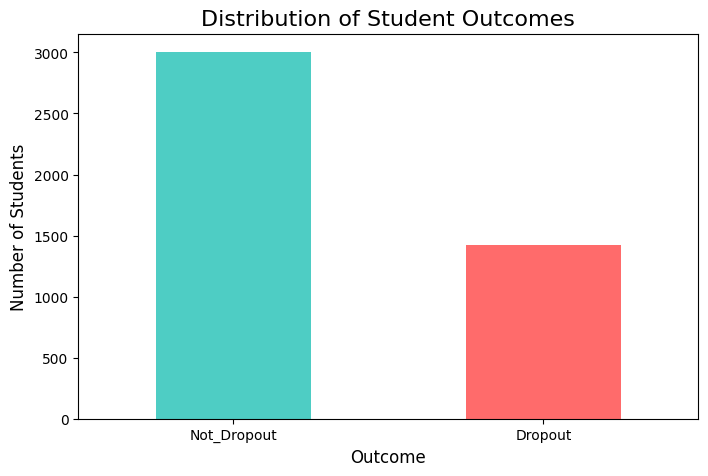

target
Not_Dropout    68.0
Dropout        32.0
Name: proportion, dtype: float64 1


In [23]:
# Target distribution
plt.figure(figsize=(8, 5))
colors = ['#4ecdc4','#ff6b6b']

df_eda['target'].value_counts().plot(kind='bar', color=colors)
plt.title('Distribution of Student Outcomes', fontsize=16)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=0)
plt.show()

print(round(df_eda['target'].value_counts(normalize=True) * 100), 1)

the data in target are not balanced,The bar chart shows that not dropout is the largest group compared to the Dropout group.

**2. Age at Enrollment**

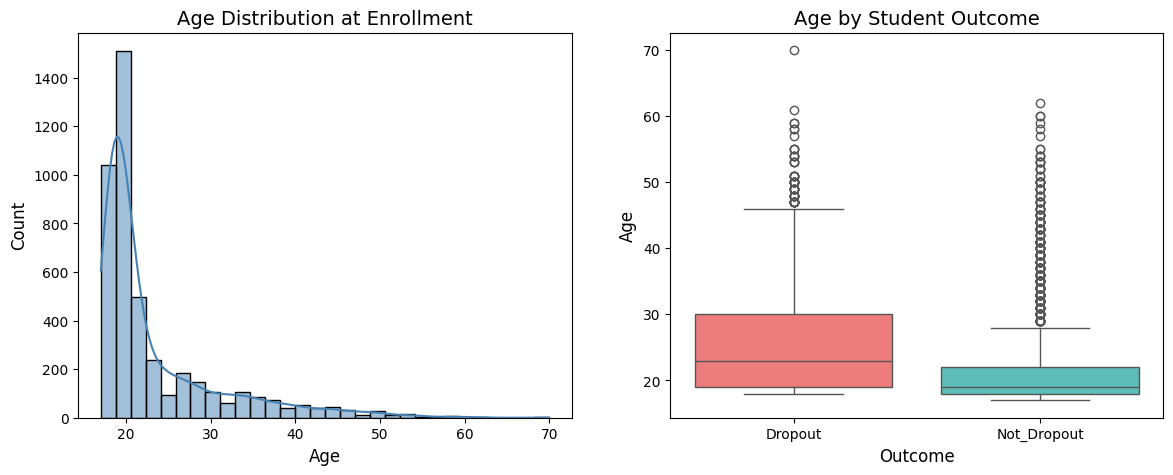

              count       mean       std   min   25%   50%   75%   max
target                                                                
Dropout      1421.0  26.068966  8.704024  18.0  19.0  23.0  30.0  70.0
Not_Dropout  3003.0  21.938395  6.596226  17.0  18.0  19.0  22.0  62.0


In [24]:
# age at the enrollment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#ff6b6b','#4ecdc4',]
# Histogram
sns.histplot(data=df_eda, x='age', bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution at Enrollment', fontsize=14)
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)


# Boxplot by outcome
sns.boxplot(data=df_eda, x='target', y='age', ax=axes[1], palette=colors)
axes[1].set_title('Age by Student Outcome', fontsize=14)
axes[1].set_xlabel('Outcome', fontsize=12)
axes[1].set_ylabel('Age', fontsize=12)

# plt.tight_layout()
plt.show()


print(df_eda.groupby('target')['age'].describe())



# Interpretation
While younger students (18-30) dominate the dataset, they also show the highest dropout rates. Older students (30+) are fewer but appear more committed, they rarely drop out


# First semester grades

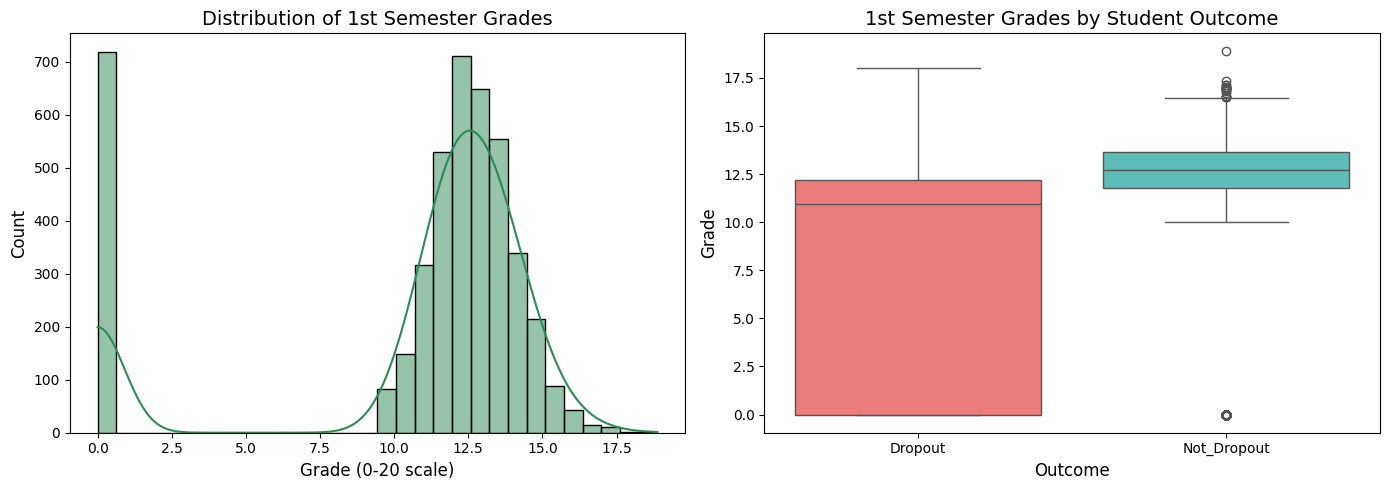

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(data=df_eda, x='sem1_grade', bins=30, kde=True, ax=axes[0], color='seagreen',)
axes[0].set_title('Distribution of 1st Semester Grades', fontsize=14)
axes[0].set_xlabel('Grade (0-20 scale)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Boxplot by outcome
sns.boxplot(data=df_eda, x='target', y='sem1_grade', ax=axes[1], palette=colors,hue='target', legend=False)
axes[1].set_title('1st Semester Grades by Student Outcome', fontsize=14)
axes[1].set_xlabel('Outcome', fontsize=12)
axes[1].set_ylabel('Grade', fontsize=12)

plt.tight_layout()
plt.show()


**Interpretetion of the grph **

# 2.Bivariate Analysis (Two Variables)

1. Students who eventually drop out have a median grade around 10–11, while not graduate have median around 13–14.

2. The distribution is nearly normal (bell-shaped), peaking between 10–14, meaning most students enter university with similar academic ability. However, dropouts show a wider spread with many students scoring below 10,



# Scholarship Status vs Outcome


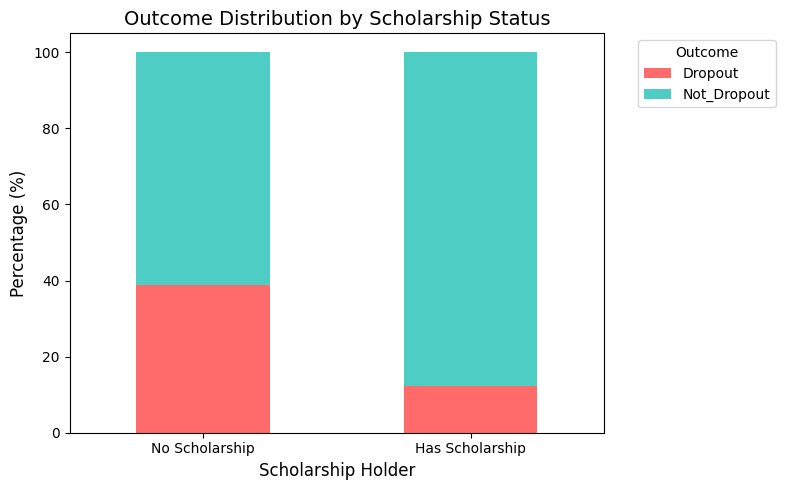

Scholarship vs Outcome (%):
target         Dropout  Not_Dropout
scholarship                        
No           38.706767    61.293233
Yes          12.192903    87.807097


In [26]:
# Cross tabulation with percentages
scholarship_outcome = pd.crosstab(df_eda['scholarship'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
scholarship_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Scholarship Status', fontsize=14)
ax.set_xlabel('Scholarship Holder', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(['No Scholarship', 'Has Scholarship'], rotation=0)
plt.tight_layout()
plt.show()

print("Scholarship vs Outcome (%):")
print(scholarship_outcome)

Interpretetion
1. Scholarship holders have a dramatically lower dropout rate  compared to non-scholarship students. dropout rates is very low around 12% for Scholarship holders whether dropout for non-scholarship is approximatelly 38%.

2. I think This is one of the strongest predictors in the dataset.

3. Expanding scholarship programs may be the single most effective intervention for reducing dropout.Every scholarship dollar appears to have a large impact


# 2 Debtor Status vs Outcome


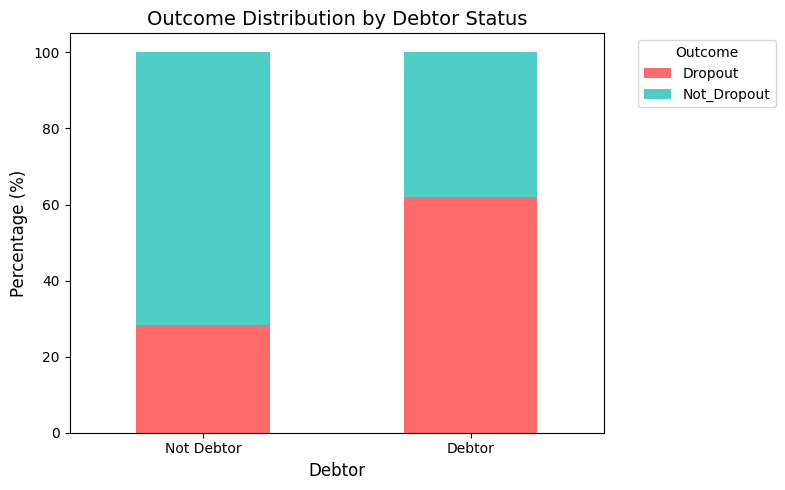

Debtor vs Outcome (%):
target    Dropout  Not_Dropout
Debtor                        
No      28.283601    71.716399
Yes     62.027833    37.972167


In [27]:
debtor_outcome = pd.crosstab(
    df_eda['Debtor'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
debtor_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Debtor Status', fontsize=14)
ax.set_xlabel('Debtor', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(['Not Debtor', 'Debtor'], rotation=0)
plt.tight_layout()
plt.show()

print("Debtor vs Outcome (%):")
print(debtor_outcome)

**Interpretation **
1. Debtors have a significantly higher dropout rate  compared to non-debtors

2. I can say Financial stress appears directly linked to leaving school.

3. Financial counseling and emergency aid programs should target identified debtors early. Even small financial interventions might prevent dropout for this group.

# 3. Marital Status vs Outcome


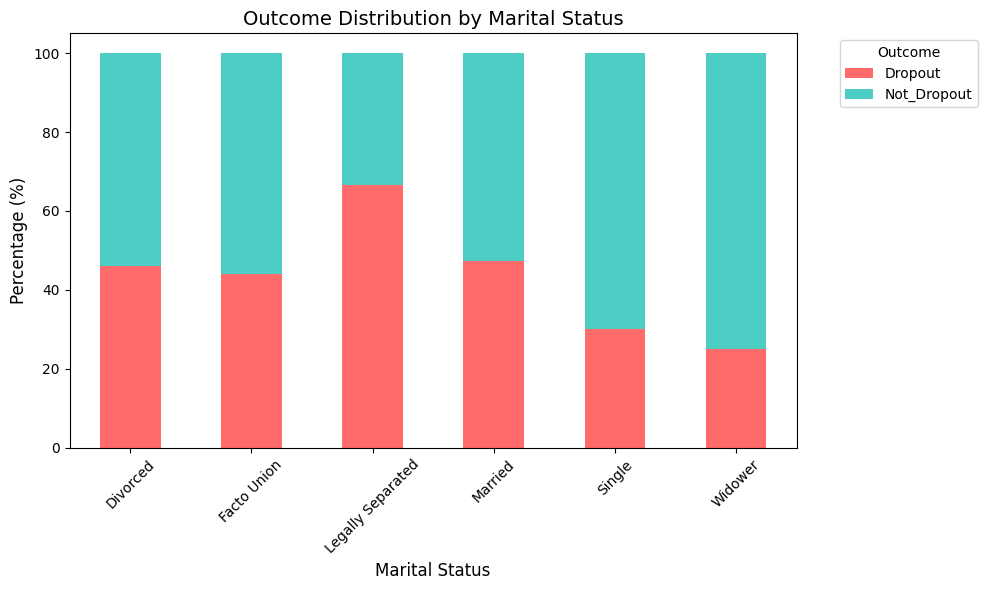

Marital Status vs Outcome (%):
target               Dropout  Not_Dropout
marital_status                           
Divorced           46.153846    53.846154
Facto Union        44.000000    56.000000
Legally Separated  66.666667    33.333333
Married            47.229551    52.770449
Single             30.211789    69.788211
Widower            25.000000    75.000000


In [28]:
marital_outcome = pd.crosstab(df_eda['marital_status'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff6b6b','#4ecdc4',]
marital_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Marital Status', fontsize=14)
ax.set_xlabel('Marital Status', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Marital Status vs Outcome (%):")
print(marital_outcome)

Interpretation

1. Legally separated students tends to dropout more compared to another marital status

2.  single students show the lowest dropout.

3. the widower students tend to not dropout compared to another marital status

# Outcome analysis by Attendance



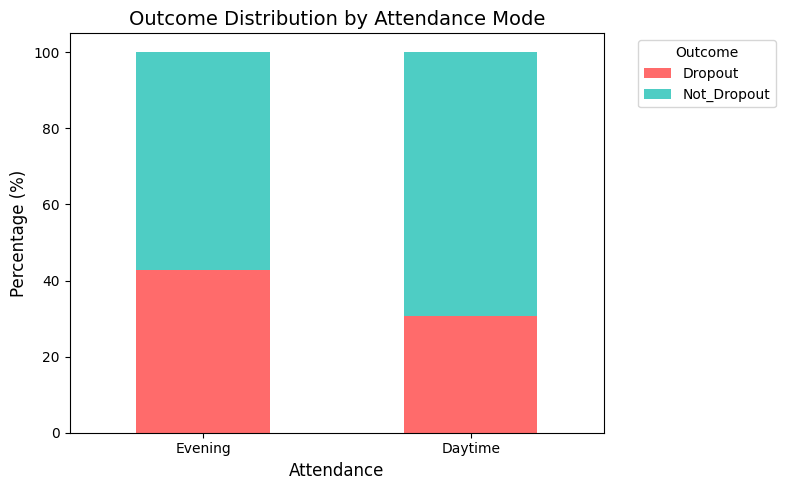

Attendance vs Outcome (%):
target                Dropout  Not_Dropout
daytime_attendance                        
No                  42.857143    57.142857
Yes                 30.804364    69.195636


In [29]:
attendance_outcome = pd.crosstab(df_eda['daytime_attendance'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#ff6b6b','#4ecdc4',]
attendance_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Attendance Mode', fontsize=14)
ax.set_xlabel('Attendance', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(['Evening', 'Daytime'], rotation=0)
plt.tight_layout()
plt.show()

print("Attendance vs Outcome (%):")
print(attendance_outcome)

The students who attends evening classes tends to dropout more compared to the student who attend daytime classes.

# 5. Correlation Analysis (Numerical Variables)

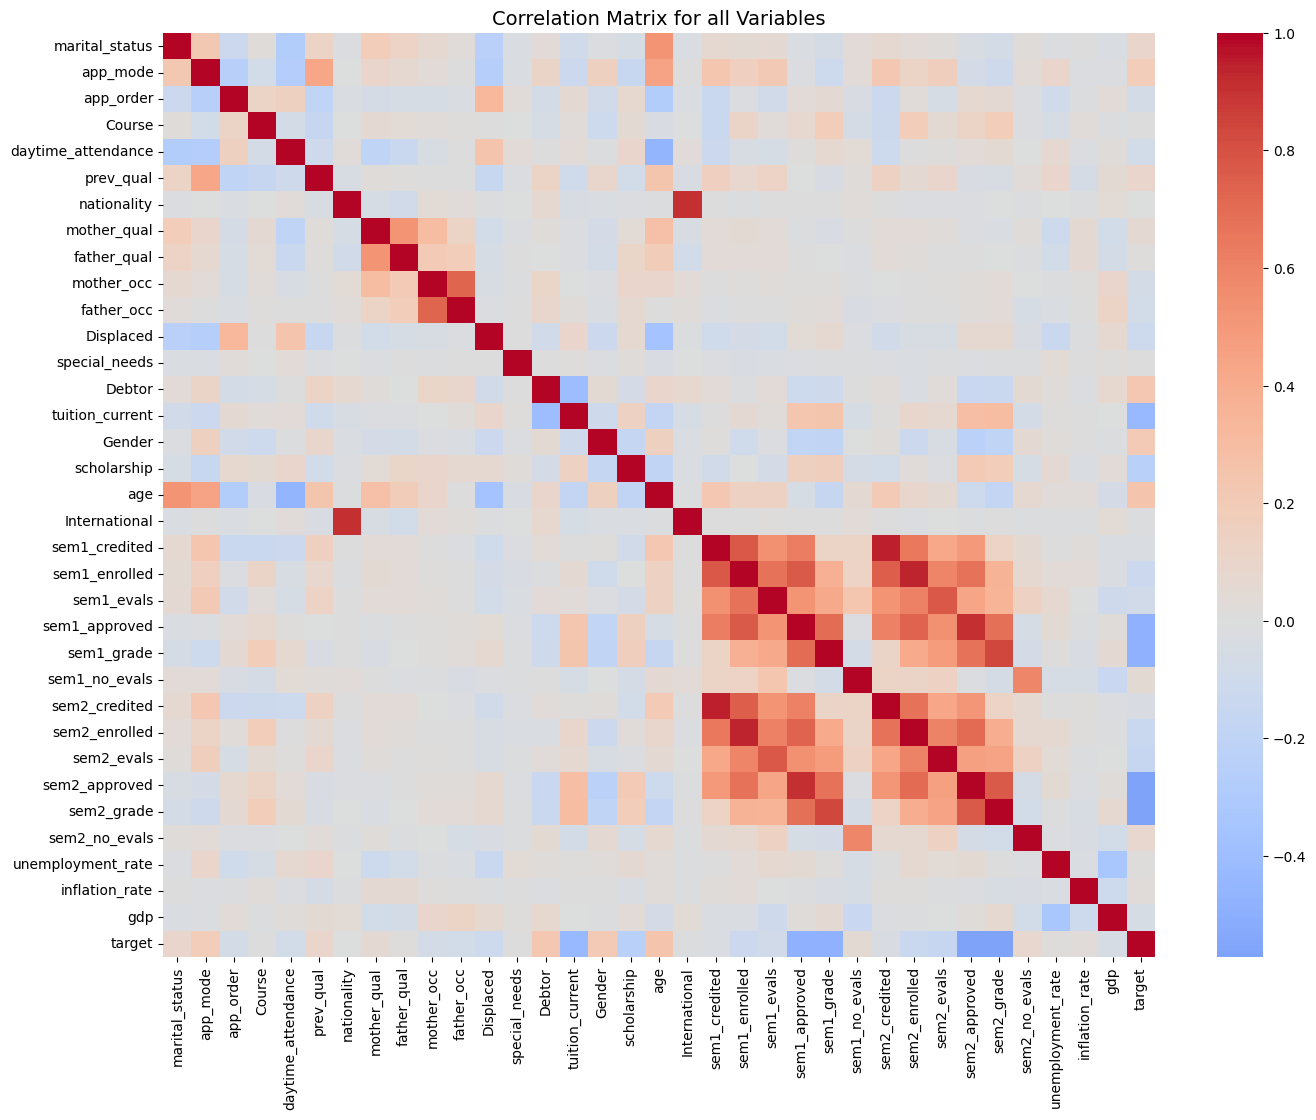

In [30]:
plt.figure(figsize=(16,12))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix for all Variables", fontsize = 14)
plt.show()

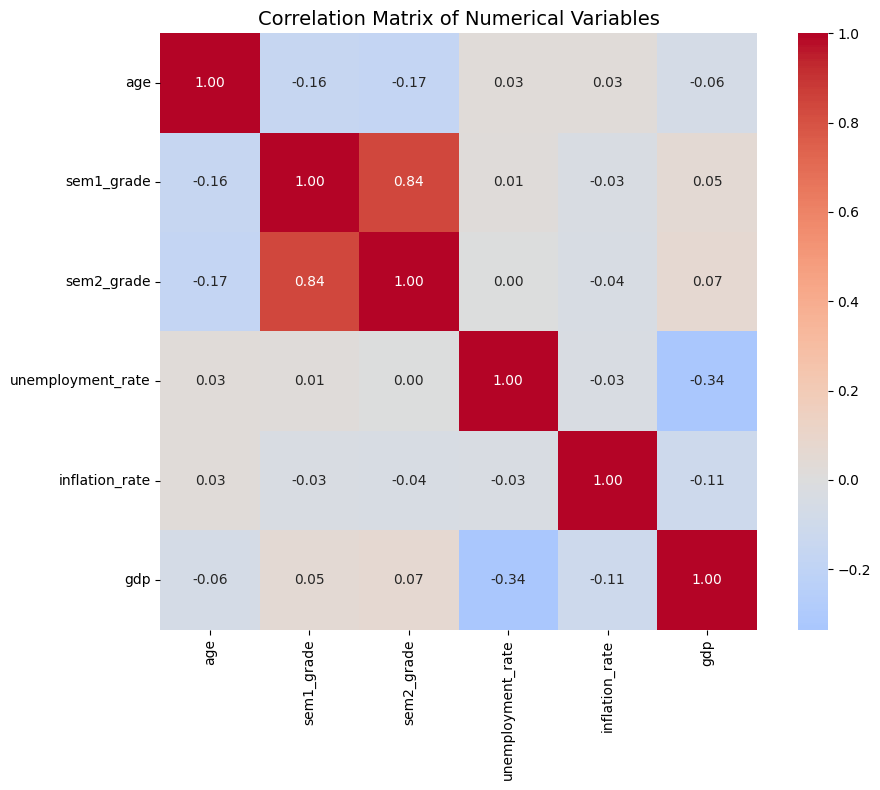

In [31]:
#  numerical columns for correlation
numerical_cols = ['age',
                  'sem1_grade',
                  'sem2_grade',
                  'unemployment_rate',
                  'inflation_rate',
                  'gdp']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix of Numerical Variables', fontsize=14)
plt.tight_layout()
plt.show()

1. there is Strong positive correlation between semester 1 and semester
2 grades it means students who do well in first semester continue doing well.

 2. Age has a weak negative correlation with both grades which means older students actually perform slightly better on average, contrary to intuition.

 3. Economic variables like unemployment_rate, inflation_rate, GDP show correlation with grades (all near 0), suggesting local economic conditions don't directly impact academic performance they may affect dropout through other mechanisms.

# Multivariate Analysis
# 1 Grades by Scholarship AND Outcome



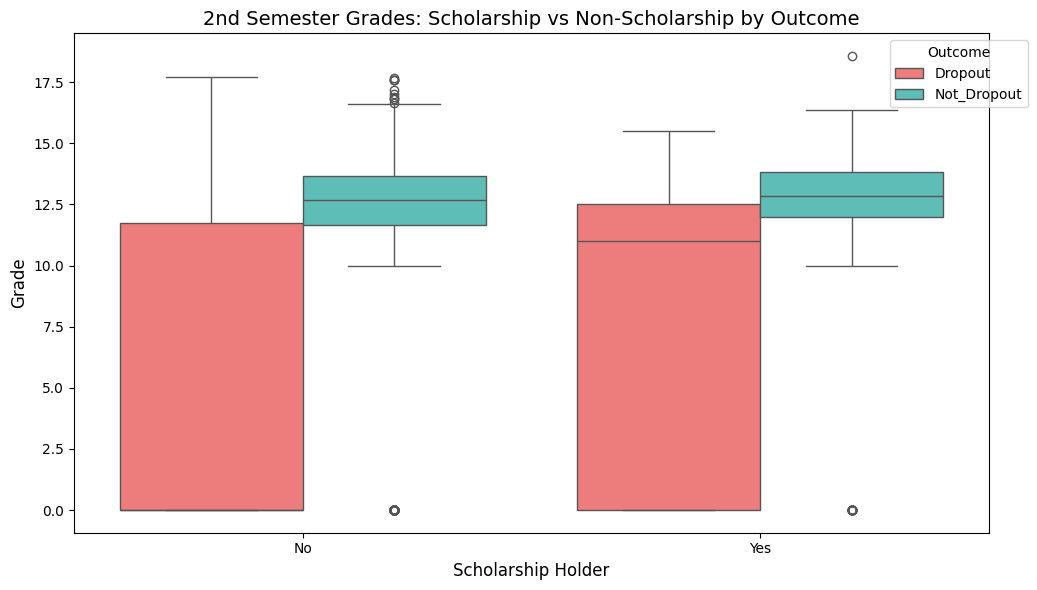

In [32]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_eda, x='scholarship', y='sem2_grade', hue='target', palette=colors)
plt.title('2nd Semester Grades: Scholarship vs Non-Scholarship by Outcome', fontsize=14)
plt.xlabel('Scholarship Holder', fontsize=12)
plt.ylabel('Grade', fontsize=12)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**Interpretation**

1. scholarship holders who drop out have grades nearly as low as non-scholarship dropouts which  means scholarship alone doesn't save a student with very poor performance.

# Analysis of outcome by age and grades


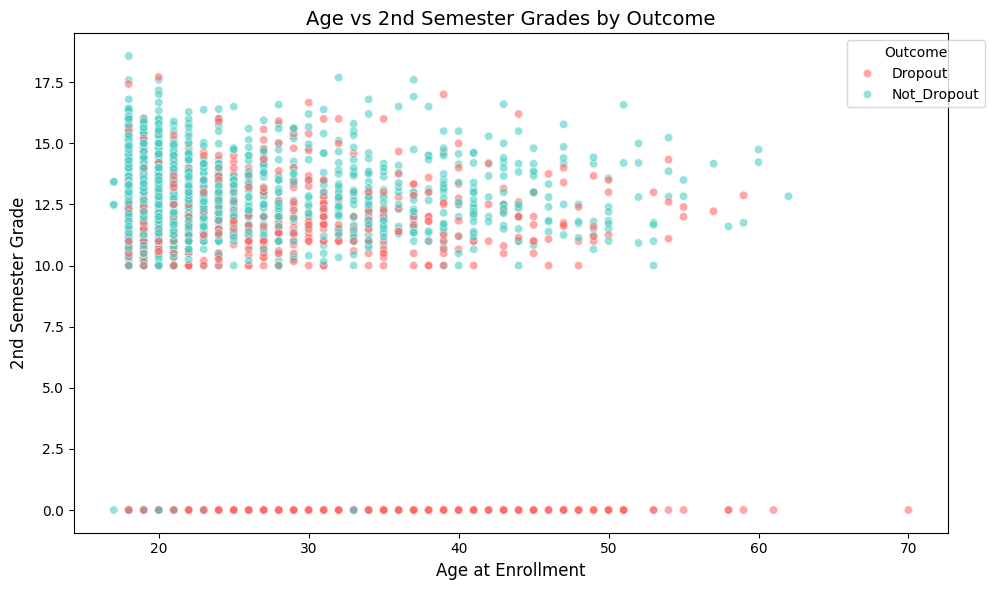

In [33]:
# ploting the outcome with age and grades

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='age', y='sem2_grade', hue='target', alpha=0.6, palette=colors)
plt.title('Age vs 2nd Semester Grades by Outcome', fontsize=14)
plt.xlabel('Age at Enrollment', fontsize=12)
plt.ylabel('2nd Semester Grade', fontsize=12)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()



**Interpretation**
1. as the most of our dataset are young peaple.

The scatter plot shows dropout students with younger age, lower grades below 10, Interestingly.


===========================================

## **Feature Engineering & Modelling**

Feature Engineering



In [35]:
# Total Approved: The sum of curricular units approved in the 1st and 2nd semesters.
df['Total_Approved'] = (
    df['sem1_approved']
    +
    df['sem2_approved']
)


# Average_Grade: The average grade across the 1st and 2nd semesters.
df['Average_Grade'] = (
    df['sem1_grade']
    +
    df['sem2_grade']
)/2

Feature-Target Split

In [36]:
X = df.drop('target', axis=1)

y = df['target']

Train-Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Feature Scaling

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Baseline Model: Dummy Classifier
It is used as a baseline to determine whether more sophisticated models are actually adding predictive value.

In [39]:
baseline = DummyClassifier(strategy='most_frequent')

baseline.fit(X_train_scaled, y_train)

baseline_pred = baseline.predict(X_test_scaled)

print(f"Baseline Accuracy (DummyClassifier): {accuracy_score(y_test, baseline_pred):.2f}")

Baseline Accuracy (DummyClassifier): 0.68


## Feature Selection

1. Filter Method (Mutual Information)

In [40]:
# Calculate MI scores
mi_scores = mutual_info_classif(
    X_train_scaled,
    y_train,
    random_state=42
    )

# Rank features
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

# Select top 15 features
top_features = mi_df.head(15)['Feature']
print(f"Top 15 Feature are:\n\n{top_features}")

Top 15 Feature are:

28      sem2_approved
34     Total_Approved
35      Average_Grade
29         sem2_grade
22      sem1_approved
23         sem1_grade
14    tuition_current
27         sem2_evals
21         sem1_evals
17                age
1            app_mode
3              Course
20      sem1_enrolled
13             Debtor
9          mother_occ
Name: Feature, dtype: object


In [42]:
import functools

# Select only to 15 best features based on mutual information
selector = SelectKBest(
    score_func=functools.partial(mutual_info_classif, random_state=42),
    k=15
)

X_train_filter = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_filter = selector.transform(
    X_test_scaled
)

# Print selected features based on their score
scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print(scores.head(15))

            Feature     Score
28    sem2_approved  0.210869
34   Total_Approved  0.203099
35    Average_Grade  0.182903
29       sem2_grade  0.176687
22    sem1_approved  0.169578
23       sem1_grade  0.142957
14  tuition_current  0.096860
27       sem2_evals  0.061291
21       sem1_evals  0.060348
17              age  0.038504
1          app_mode  0.037438
3            Course  0.036800
20    sem1_enrolled  0.034029
13           Debtor  0.028854
9        mother_occ  0.026313


In [43]:
# Print selected features based on their score
scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print(scores.head(15))

            Feature     Score
28    sem2_approved  0.210869
34   Total_Approved  0.203099
35    Average_Grade  0.182903
29       sem2_grade  0.176687
22    sem1_approved  0.169578
23       sem1_grade  0.142957
14  tuition_current  0.096860
27       sem2_evals  0.061291
21       sem1_evals  0.060348
17              age  0.038504
1          app_mode  0.037438
3            Course  0.036800
20    sem1_enrolled  0.034029
13           Debtor  0.028854
9        mother_occ  0.026313


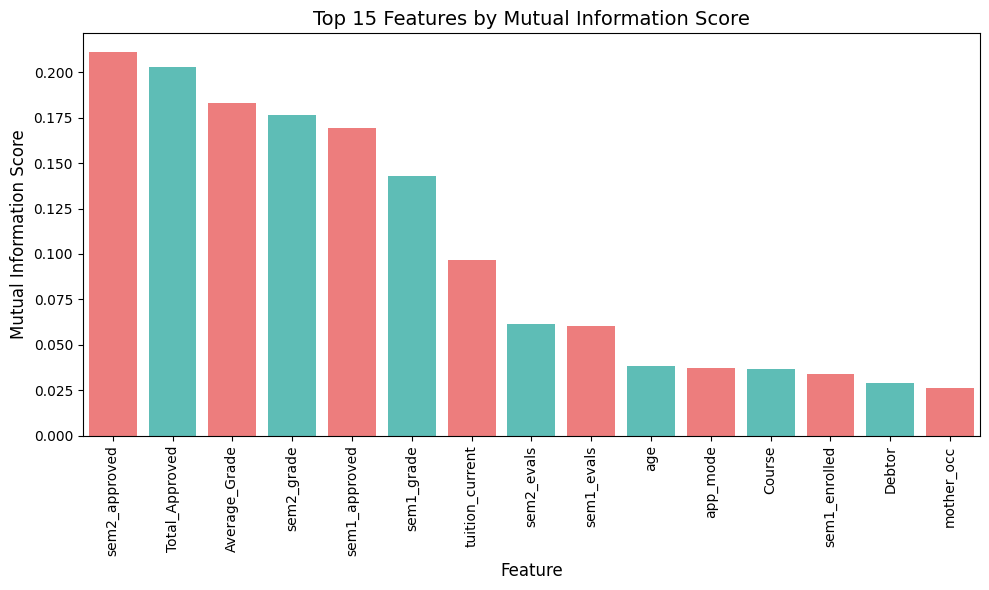

In [46]:
# plot a bar chart with feature name and the score
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Score', data=scores.head(15), palette=colors)
plt.title('Top 15 Features by Mutual Information Score', fontsize=14)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Mutual Information Score', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

2. Wrapper Method (RFE)

In [48]:
rfe_model = LogisticRegression(
    max_iter=1000
)

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=15
)

X_train_rfe = rfe.fit_transform(
    X_train_scaled,
    y_train
)

X_test_rfe = rfe.transform(
    X_test_scaled
)

# print selected features
selected_features = X.columns[rfe.support_]
print(selected_features)

Index(['Course', 'nationality', 'mother_occ', 'tuition_current', 'scholarship',
       'age', 'International', 'sem1_enrolled', 'sem1_approved', 'sem1_grade',
       'sem2_credited', 'sem2_enrolled', 'sem2_approved', 'sem2_grade',
       'Total_Approved'],
      dtype='object')


3. Embedded Method

In [51]:
# Create a Random Forest classifier

rf_fs = RandomForestClassifier(
    random_state=42
)

# Train the model using the training data
rf_fs.fit(
    X_train,
    y_train
)

# Create a DataFrame containing:
# - Feature names
# - Their importance scores from the Random Forest
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_fs.feature_importances_
})

# Sort features by importance (highest first)
# and display the top 15 most important features
importance_df.sort_values(
    by='Importance',
    ascending=False
).head(15)

,Feature,Importance
28,sem2_approved,0.111318
34,Total_Approved,0.106268
35,Average_Grade,0.085502
29,sem2_grade,0.080997
22,sem1_approved,0.065273
14,tuition_current,0.060812
23,sem1_grade,0.057170
17,age,0.036286
3,Course,0.034876
10,father_occ,0.027564


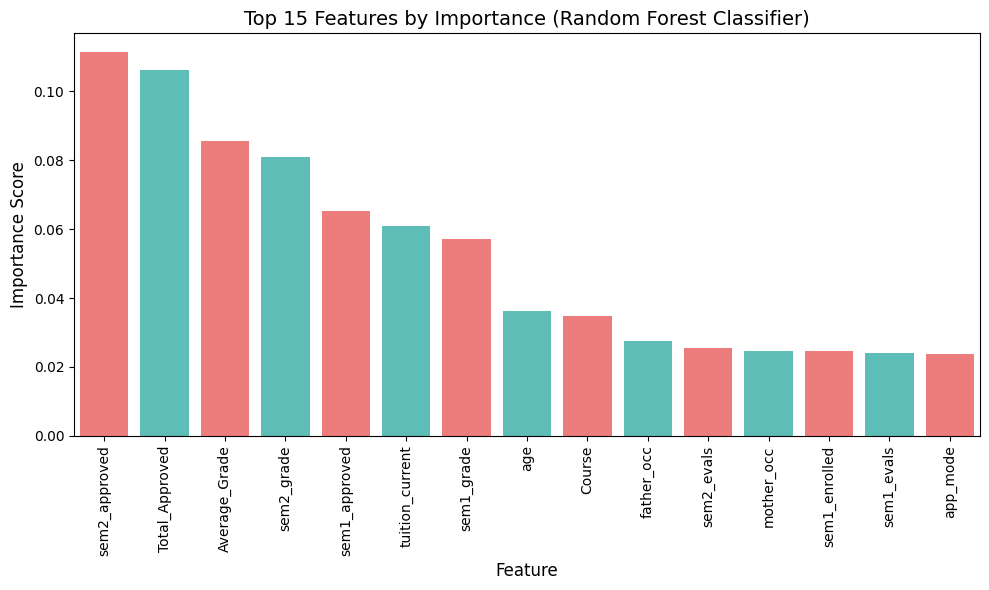

In [53]:
# Plot the most important features using bar chart with their importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Feature',
    y='Importance',
    data=importance_df.sort_values(
        by='Importance',
        ascending=False
    ).head(15),
    palette=colors
)
plt.title('Top 15 Features by Importance (Random Forest Classifier)', fontsize=14)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## PCA: Principal Component Analysis

In [54]:
pca = PCA()

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)



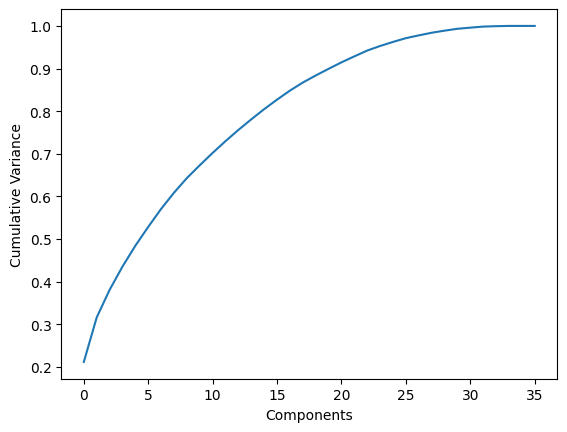

In [55]:
# Explained Variance
#explained_variance = pca.explained_variance_ratio_

# Cumulative Explained Variance
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.plot(cumulative_variance)

plt.xlabel("Components")
plt.ylabel("Cumulative Variance")

plt.show()

In [56]:
# Retain 95% Variance
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

print(
    "Components retained:",
    pca.n_components_
)

Components retained: 24


## **MODEL TRAINING FUNCTION**

In [59]:
#This function trains a classification model, makes predictions, calculates several evaluation metrics, and returns them in a dictionary.
# Function to train and evaluate a classification model
def evaluate_model(model,
                   X_train,
                   X_test,
                   y_train,
                   y_test):

    # Train the model on the training data
    model.fit(
        X_train,
        y_train
    )

    # Predict class labels (e.g., 0 or 1)
    pred = model.predict(X_test)

    # Predict probabilities for each class
    # [:,1] selects the probability of the positive class (class 1)
    prob = model.predict_proba(
        X_test
    )[:,1]

    # Return evaluation metrics as a dictionary
    return {

        # Overall percentage of correct predictions
        "Accuracy":
        accuracy_score(
            y_test,
            pred
        ),

        # Of all predicted positives, how many were actually positive?
        "Precision":
        precision_score(
            y_test,
            pred
        ),

        # Of all actual positives, how many were found?
        "Recall":
        recall_score(
            y_test,
            pred
        ),

        # Harmonic mean of Precision and Recall
        "F1":
        f1_score(
            y_test,
            pred
        ),

        # Measures ranking quality using predicted probabilities
        "ROC_AUC":
        roc_auc_score(
            y_test,
            prob
        )
    }

## **MODELS**

In [60]:
# Dictionary containing model names and model objects

models = {

    # Logistic Regression classifier
    # max_iter=1000 gives the optimizer more iterations to converge
    "Logistic Regression":
    LogisticRegression(
        max_iter=1000
    ),

    # Single Decision Tree classifier
    "Decision Tree":
    DecisionTreeClassifier(
        random_state=42
    ),

    # Random Forest classifier: Ensemble of many decision trees
    "Random Forest":
    RandomForestClassifier(
        random_state=42
    ),

    # XGBoost classifier
    # eval_metric='logloss' specifies the evaluation metric during training
    "XGBoost":
    XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )
}

## **Experimentation**

In [61]:
# Experiment 1: Train models using ALL features

results_all = []  # Empty list to store results

for name, model in models.items():

    # Train model and calculate evaluation metrics
    scores = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    # Add the model name to the results dictionary
    scores['Model'] = name

    # Store the results
    results_all.append(scores)

# Convert list of dictionaries into a DataFrame
results_all = pd.DataFrame(results_all)

# Display results
results_all

,Accuracy,Precision,Recall,F1,ROC_AUC,Model
0,0.879096,0.873418,0.728873,0.794626,0.928839,Logistic Regression
1,0.795480,0.672241,0.707746,0.689537,0.772342,Decision Tree
2,0.884746,0.872951,0.750000,0.806818,0.929194,Random Forest
3,0.885876,0.853282,0.778169,0.813996,0.924644,XGBoost


In [63]:
# Experiment 2: Feature Selection (Mutual Information + Select Best 15)

results_fs = []  # Store results for the feature-selection experiment

# Loop through each model in the dictionary
for name, model in models.items():

    # Train the model using only the selected features
    # and calculate evaluation metrics
    scores = evaluate_model(
        model,
        X_train_filter,
        X_test_filter,
        y_train,
        y_test
    )

    # Add model name to the results
    scores['Model'] = name

    # Save results
    results_fs.append(scores)

# Convert list of dictionaries into a DataFrame
results_fs = pd.DataFrame(results_fs)
results_fs

,Accuracy,Precision,Recall,F1,ROC_AUC,Model
0,0.877966,0.879310,0.718310,0.790698,0.917508,Logistic Regression
1,0.819209,0.710884,0.735915,0.723183,0.801106,Decision Tree
2,0.868927,0.836000,0.735915,0.782772,0.908908,Random Forest
3,0.867797,0.835341,0.732394,0.780488,0.914268,XGBoost


In [66]:
# Experiment 3: Recursive Feature Elimination (RFE)

results_rfe = []

for name, model in models.items():

    scores = evaluate_model(
        model,
        X_train_rfe,
        X_test_rfe,
        y_train,
        y_test
    )

    scores['Model'] = name

    results_rfe.append(scores)

results_rfe = pd.DataFrame(results_rfe)

results_rfe

,Accuracy,Precision,Recall,F1,ROC_AUC,Model
0,0.879096,0.864198,0.739437,0.796964,0.926616,Logistic Regression
1,0.803390,0.695035,0.690141,0.692580,0.789854,Decision Tree
2,0.872316,0.843373,0.739437,0.787992,0.916360,Random Forest
3,0.873446,0.835938,0.753521,0.792593,0.910123,XGBoost


In [65]:
# Experiment 4: Principal Component Analysis (PCA)

results_pca = []

# Loop through each model
for name, model in models.items():

    # Train and evaluate the model using PCA features
    scores = evaluate_model(
        model,
        X_train_pca,
        X_test_pca,
        y_train,
        y_test
    )

    # Add model name to the results
    scores['Model'] = name

    # Store results
    results_pca.append(scores)

# Convert results into a DataFrame
results_pca = pd.DataFrame(results_pca)
results_pca

,Accuracy,Precision,Recall,F1,ROC_AUC,Model
0,0.875706,0.884956,0.704225,0.784314,0.924058,Logistic Regression
1,0.786441,0.655738,0.704225,0.679117,0.764758,Decision Tree
2,0.850847,0.833333,0.669014,0.742188,0.909511,Random Forest
3,0.854237,0.821577,0.697183,0.754286,0.912634,XGBoost


## **Model** **comparison**

In [79]:
# Combine the results from all experiments into one DataFrame
comparison = pd.concat([
    results_all,    # Experiment 1: All Features
    results_fs,     # Experiment 2: Mutual Information Feature Selection
    results_rfe,    # Experiment 3: Recursive Feature Elimination (RFE)
    results_pca     # Experiment 4: Principal Component Analysis (PCA)
], ignore_index=True)

# Display the combined results
comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.879096,0.873418,0.728873,0.794626,0.928839,Logistic Regression,All Features
1,0.795480,0.672241,0.707746,0.689537,0.772342,Decision Tree,All Features
2,0.884746,0.872951,0.750000,0.806818,0.929194,Random Forest,All Features
3,0.885876,0.853282,0.778169,0.813996,0.924644,XGBoost,All Features
4,0.877966,0.879310,0.718310,0.790698,0.917508,Logistic Regression,Mutual Information
5,0.819209,0.710884,0.735915,0.723183,0.801106,Decision Tree,Mutual Information
6,0.868927,0.836000,0.735915,0.782772,0.908908,Random Forest,Mutual Information
7,0.867797,0.835341,0.732394,0.780488,0.914268,XGBoost,Mutual Information
8,0.879096,0.864198,0.739437,0.796964,0.926616,Logistic Regression,RFE
9,0.803390,0.695035,0.690141,0.692580,0.789854,Decision Tree,RFE


In [87]:
comparison.sort_values(
    by='F1',
    ascending=False
).head(1)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment,Score
3,0.885876,0.853282,0.778169,0.813996,0.924644,XGBoost,All Features,0.86932


In [86]:
comparison.sort_values(by='ROC_AUC', ascending=False).head(1)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment,Score
2,0.884746,0.872951,0.75,0.806818,0.929194,Random Forest,All Features,0.868006


In [85]:
comparison['Score'] = (
    0.5 * comparison['ROC_AUC'] +
    0.5 * comparison['F1']
)

best_model = comparison.sort_values(
    by='Score',
    ascending=False
).head(1)
best_model

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment,Score
3,0.885876,0.853282,0.778169,0.813996,0.924644,XGBoost,All Features,0.86932


## **Tuning the best model based on F1**

In [93]:

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91       601
           1       0.85      0.75      0.80       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



## **Confusion Matrix**

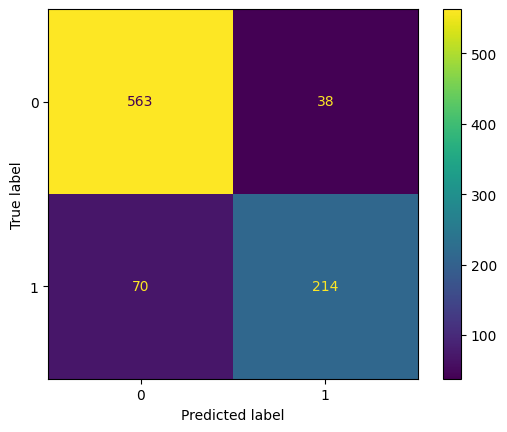

In [101]:
# Get the best model from GridSearchCV
best_model = grid.best_estimator_

# Make predictions on the test set
pred = best_model.predict(
    X_test_scaled
)

# Compute confusion matrix
cm = confusion_matrix(
    y_test,
    pred
)

# Display confusion matrix visually
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

# Show the plot
plt.show()

## **Feature Importance**

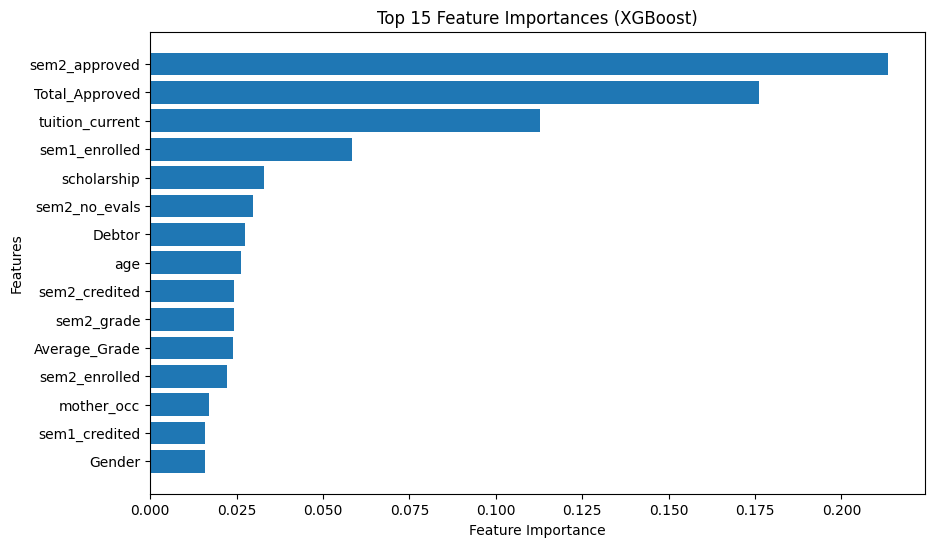

In [100]:

# Sort and take top 15 features
top_features = importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    top_features['Feature'][::-1],      # reverse for descending order
    top_features['Importance'][::-1]
)

# Labels and title
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.show()

=====================================
